# Optimization Using Gradient Descent in One Variable

To understand how to optimize functions using gradient descent, we start with simple examples – functions of one variable.  
In this notebook, we implement the gradient descent method for functions with:

- One global minimum  
- Multiple minima  

We experiment with parameters and visualize the results to understand the strengths and limitations of gradient descent.


## Packages

We only use standard Python libraries that are available by default.


In [15]:
import numpy as np
import matplotlib.pyplot as plt

## 1 – Function with One Global Minimum

Consider the function:

\[
f(x) = e^x - \log(x), \quad x > 0
\]

This function has a **single global minimum**, but solving  
\[
\frac{df}{dx} = 0
\]
analytically is not straightforward. Instead, we use **gradient descent**.


In [16]:
def f_example_1(x):
    return np.exp(x) - np.log(x)

def dfdx_example_1(x):
    return np.exp(x) - 1/x

### Plotting the function


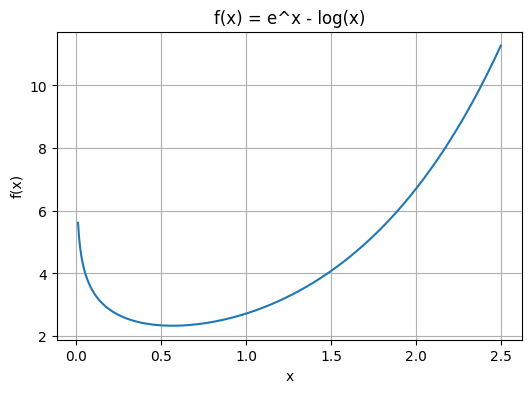

In [17]:
x_vals = np.linspace(0.01, 2.5, 400)
y_vals = f_example_1(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = e^x - log(x)")
plt.grid(True)
plt.show()


### Gradient Descent Algorithm

Gradient descent updates the variable using:

\[
x_{n+1} = x_n - \alpha \frac{df}{dx}(x_n)
\]

where:
- \(\alpha\) is the **learning rate**
- \(n\) is the iteration number


In [18]:
def gradient_descent(dfdx, x, learning_rate=0.1, num_iterations=100):
    for _ in range(num_iterations):
        x = x - learning_rate * dfdx(x)
    return x


### Running Gradient Descent


In [19]:
num_iterations = 25
learning_rate = 0.1
x_initial = 1.6

x_min = gradient_descent(dfdx_example_1, x_initial, learning_rate, num_iterations)
print("Gradient descent result: x_min =", x_min)


Gradient descent result: x_min = 0.5671434156768685


### Visualizing the result


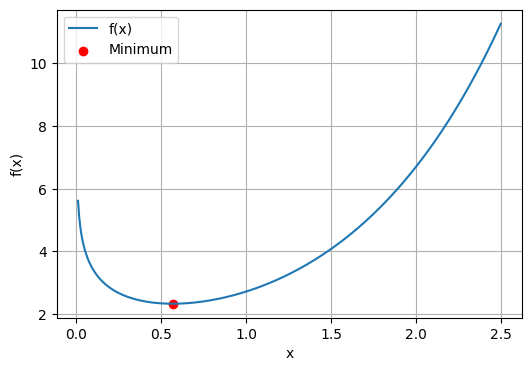

In [20]:
plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals, label="f(x)")
plt.scatter(x_min, f_example_1(x_min), color="red", label="Minimum")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()


## Observations

- A reasonable learning rate leads to fast convergence.
- Too large a learning rate causes divergence.
- Too small a learning rate converges very slowly.
- The initial point affects stability.


## 2 – Function with Multiple Minima

Now consider a function with **multiple minima**.  
Gradient descent may converge to a **local minimum**, depending on the starting point.


In [21]:
def f_example_2(x):
    return x**4 - 3*x**3 + 2

def dfdx_example_2(x):
    return 4*x**3 - 9*x**2


### Plotting the function with multiple minima


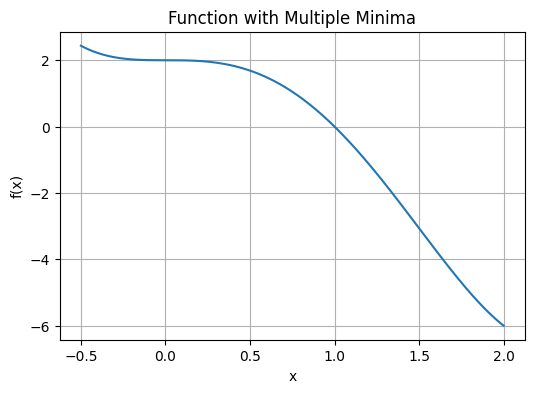

In [22]:
x_vals = np.linspace(-0.5, 2, 400)
y_vals = f_example_2(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function with Multiple Minima")
plt.grid(True)
plt.show()


### Running Gradient Descent from Different Starting Points
